# SAA+ Benchmark Report

Zero-shot anomaly segmentation results on **MVTec-AD** and **VisA** datasets.

Paper: *Segment Any Anomaly without Training via Hybrid Prompt Regularization* (arXiv 2305.10724)

Primary metrics per paper:
- **Fp (max-F1-pixel / `p_f1`)**: pixel-wise F1 at optimal threshold
- **Fr (max-F1-region / `r_f1`)**: region-wise F1 at optimal threshold (overlap > 0.6) — not computed here

Paper reference numbers (Table 1): **MVTec Fp = 39.40**, **VisA Fp = 27.07**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Paper reference values (Table 1, SAA+)
PAPER = {
    'MVTec': {'Fp': 39.40, 'Fr': 49.67},
    'VisA':  {'Fp': 27.07, 'Fr': 14.46},
}

In [6]:
from pathlib import Path

# Search for CSVs: local Downloads (Mac) → repo result/csv/ (Colab)
_here = Path().resolve()
_candidates = [
    Path.home() / 'Downloads',
    _here / 'result' / 'csv',
    _here.parent / 'result' / 'csv',
]
CSV_DIR = next((p for p in _candidates if (p / 'mvtec-indx-0.csv').exists()), None)
assert CSV_DIR is not None, f"CSV not found in any of: {_candidates}"
print(f"Reading CSVs from: {CSV_DIR}")

REPO_ROOT = _here if (_here / 'report').exists() else _here.parent
REPORT_DIR = REPO_ROOT / 'report'

mvtec = pd.read_csv(CSV_DIR / 'mvtec-indx-0.csv', index_col=0)
visa  = pd.read_csv(CSV_DIR / 'visa_public-indx-0.csv', index_col=0)

# Clean VisA index (strip 'visa_public-' prefix for display)
visa.index = visa.index.str.replace('visa_public-', '', regex=False)

COLS = ['i_roc', 'p_roc', 'i_ap', 'p_ap', 'i_f1', 'p_f1']

def with_mean(df):
    mean = df[COLS].mean().rename('MEAN')
    return pd.concat([df[COLS], mean.to_frame().T])

mvtec_full = with_mean(mvtec)
visa_full  = with_mean(visa)

Reading CSVs from: /Users/april/Downloads


## MVTec-AD Results

In [7]:
mvtec_full.style \
    .format('{:.2f}') \
    .highlight_max(subset=COLS, axis=0, color='#c6efce') \
    .highlight_min(subset=COLS, axis=0, color='#ffc7ce') \
    .set_caption('MVTec-AD — per-class metrics (green=best, red=worst)')

,i_roc,p_roc,i_ap,p_ap,i_f1,p_f1
carpet,94.23,70.06,97.71,38.02,94.12,55.98
grid,71.56,60.12,91.11,14.17,84.75,23.72
leather,100.00,84.07,100.00,66.14,100.00,75.76
tile,94.58,74.46,98.20,44.66,95.65,47.01
wood,98.56,80.83,99.60,55.38,98.04,64.22
bottle,82.69,67.77,94.65,27.49,90.57,38.07
cable,37.00,61.27,60.22,18.35,76.36,25.30
capsule,42.26,63.36,81.11,9.60,90.32,18.15
hazelnut,99.62,84.54,99.80,54.05,97.78,66.99
metal_nut,37.04,60.43,77.85,13.16,88.52,33.68


## VisA Results

In [8]:
visa_full.style \
    .format('{:.2f}') \
    .highlight_max(subset=COLS, axis=0, color='#c6efce') \
    .highlight_min(subset=COLS, axis=0, color='#ffc7ce') \
    .set_caption('VisA — per-class metrics (green=best, red=worst)')

,i_roc,p_roc,i_ap,p_ap,i_f1,p_f1
candle,56.46,50.41,59.62,0.23,69.09,1.59
capsules,66.83,91.31,81.58,58.71,78.79,71.13
cashew,77.04,52.21,90.46,3.92,81.16,7.22
chewinggum,88.78,93.42,95.39,79.58,89.29,85.26
fryum,34.69,96.37,63.40,69.14,80.00,71.71
macaroni1,74.38,74.52,82.10,18.99,70.59,33.10
macaroni2,70.52,70.67,80.33,22.88,68.75,38.58
pcb1,62.81,73.18,75.87,10.59,66.67,31.58
pcb2,73.92,83.05,80.69,1.59,73.17,5.44
pcb3,62.13,62.28,72.80,1.36,68.29,8.61


## Summary vs Paper (primary metrics)

In [9]:
mvtec_fp = mvtec['p_f1'].mean()
visa_fp  = visa['p_f1'].mean()

summary = pd.DataFrame({
    'Dataset':    ['MVTec-AD', 'VisA'],
    'Fp (paper)': [PAPER['MVTec']['Fp'], PAPER['VisA']['Fp']],
    'Fp (ours)':  [mvtec_fp, visa_fp],
    'Delta Fp':   [mvtec_fp - PAPER['MVTec']['Fp'], visa_fp - PAPER['VisA']['Fp']],
}).set_index('Dataset')

def color_delta(v):
    return 'color: green' if v > 0 else 'color: red'

summary.style \
    .format({'Fp (paper)': '{:.2f}', 'Fp (ours)': '{:.2f}', 'Delta Fp': '{:+.2f}'}) \
    .map(color_delta, subset=['Delta Fp']) \
    .set_caption('max-F1-pixel (Fp): ours vs paper (Table 1)')

,Fp (paper),Fp (ours),Delta Fp
Dataset,,,
MVTec-AD,39.40,40.06,+0.66
VisA,27.07,35.92,+8.85


## Per-class Fp bar charts

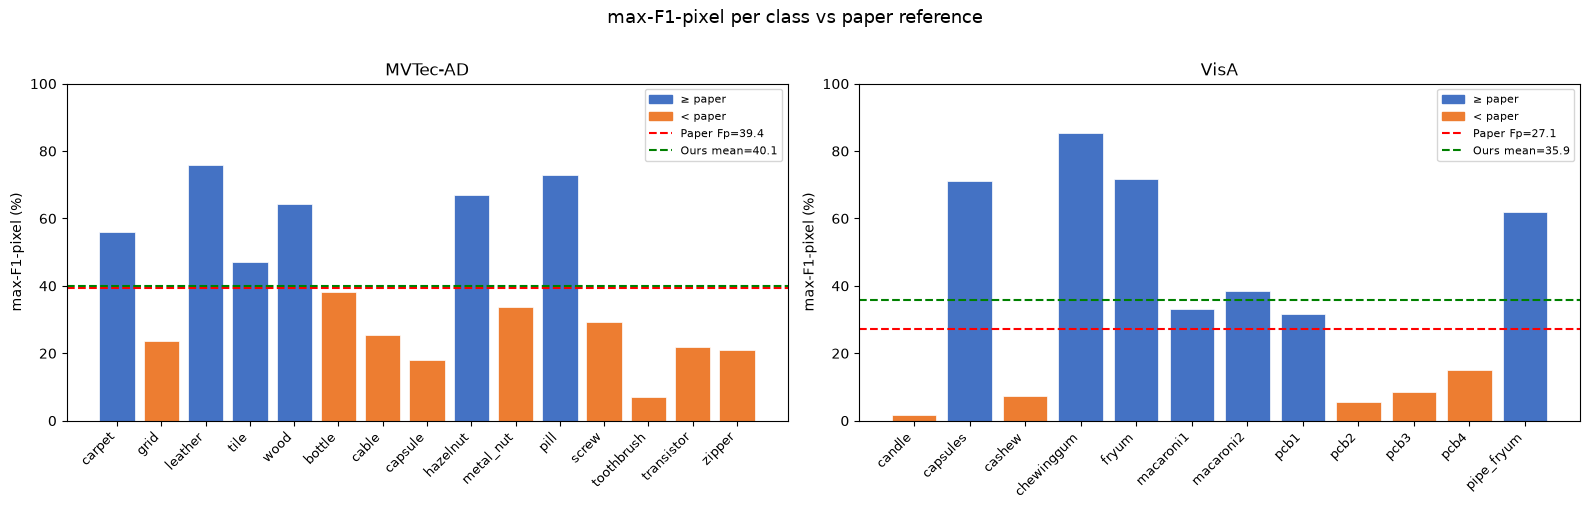

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, label, paper_fp in [
    (axes[0], mvtec, 'MVTec-AD', PAPER['MVTec']['Fp']),
    (axes[1], visa,  'VisA',     PAPER['VisA']['Fp']),
]:
    vals = df['p_f1']
    colors = ['#4472c4' if v >= paper_fp else '#ed7d31' for v in vals]
    ax.bar(range(len(vals)), vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(paper_fp, color='red', linestyle='--', linewidth=1.5)
    ax.axhline(vals.mean(), color='green', linestyle='--', linewidth=1.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('max-F1-pixel (%)')
    ax.set_ylim(0, 100)
    ax.set_title(label)
    ax.legend(handles=[
        mpatches.Patch(color='#4472c4', label='\u2265 paper'),
        mpatches.Patch(color='#ed7d31', label='< paper'),
        plt.Line2D([0],[0], color='red',   linestyle='--', label=f'Paper Fp={paper_fp:.1f}'),
        plt.Line2D([0],[0], color='green', linestyle='--', label=f'Ours mean={vals.mean():.1f}'),
    ], fontsize=8)

plt.suptitle('max-F1-pixel per class vs paper reference', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'fp_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## Metric heatmap (supplementary)

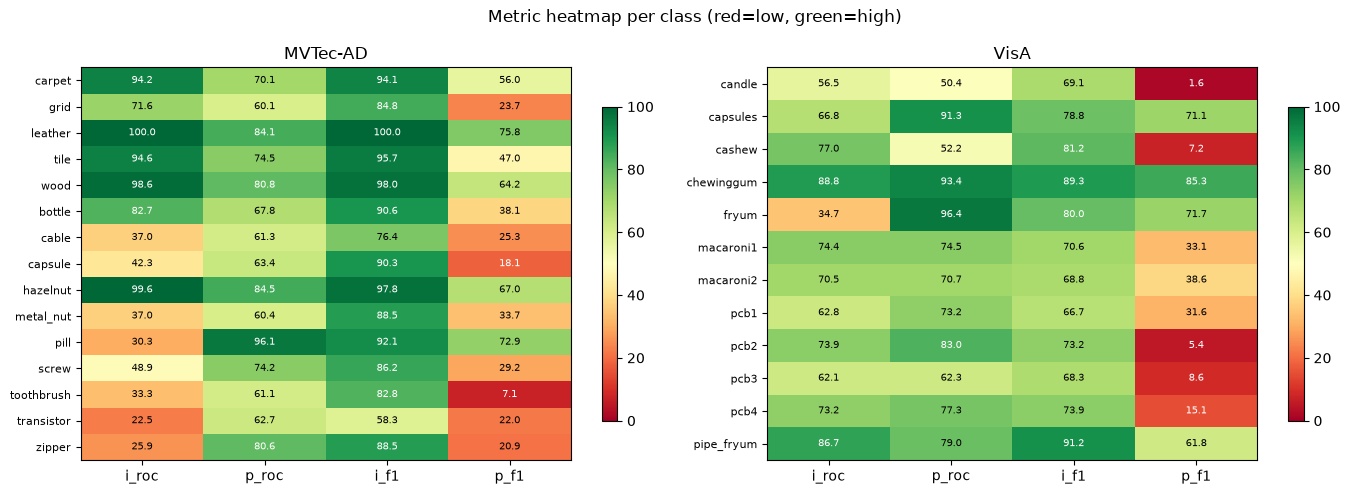

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in [
    (axes[0], mvtec, 'MVTec-AD'),
    (axes[1], visa,  'VisA'),
]:
    display_cols = ['i_roc', 'p_roc', 'i_f1', 'p_f1']
    data = df[display_cols]
    im = ax.imshow(data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
    ax.set_xticks(range(len(display_cols)))
    ax.set_xticklabels(display_cols, fontsize=10)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(label)
    for i in range(len(data)):
        for j in range(len(display_cols)):
            v = data.values[i, j]
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                    color='black' if 20 < v < 80 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Metric heatmap per class (red=low, green=high)', fontsize=12)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'metric_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Note: max-F1-region (Fr)

`r_f1` is currently disabled in `utils/metrics.py` (line 43, `calculate_max_f1_region` is commented out).

Paper reference: **MVTec Fr = 49.67**, **VisA Fr = 14.46**

Enable by uncommenting the call and setting `--cal-pro True` in `run_MVTec.py` / `run_VisA_public.py`, then re-running the benchmark.